In [11]:
# ===== LIBRERÍAS =====
import time
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import StratifiedKFold, train_test_split


In [12]:
class ShmaliyDegreeSpecialist(layers.Layer):
    def __init__(self, degree, N=100, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.degree = degree
        self.units = degree + 1  # 1 neurona por grado
        self.N = float(N)
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Cada grado tiene su vector de pesos
        self.kernel = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel_specialist"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias_specialist"
            )

    def call(self, inputs):
        x = tf.cast(inputs, self.compute_dtype)

        # Escalado
        k_vals = (x + 1.0) * (self.N - 1.0) / 2.0

        # S0 y S1
        s0 = tf.ones_like(k_vals)
        s1 = 1.0 - (2.0 * k_vals) / (self.N - 1.0)

        polys = [s0, s1]

        prev_prev = s0
        prev = s1

        for k in range(1, self.degree):
            denom = (k + 1.0) * (self.N - 1.0 - k)

            term1 = ((2.0 * k + 1.0) * (self.N - 1.0 - 2.0 * k_vals) * prev) / denom
            term2 = (k * (self.N + k) * prev_prev) / denom

            current = term1 - term2

            polys.append(current)

            prev_prev = prev
            prev = current

        # (batch, grado, features)
        stacked = tf.stack(polys, axis=1)

        # einsum: cada grado se multiplica por su vector de pesos correspondiente
        output = tf.einsum('bgf,fu->bu', stacked, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

In [13]:
def create_model(degree, N_value, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = ShmaliyDegreeSpecialist(degree=degree, N=N_value)(inputs)
    x = layers.Activation('swish')(x)

    x = layers.Dense(16, activation='swish')(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, output)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
# ===== PLOT =====
def plot_cv_average_history(histories_Shy):
    max_epochs_cheb = max([len(h.history['loss']) for h in histories_Shy])
    epochs_cheb = np.arange(1, max_epochs_cheb + 1)

    def get_padded_metrics_cheb(metric_name):
        matrix_cheb = np.full((len(histories_Shy), max_epochs_cheb), np.nan)
        for i, h in enumerate(histories_Shy):
            data_cheb = h.history[metric_name]
            matrix_cheb[i, :len(data_cheb)] = data_cheb
        return np.nanmean(matrix_cheb, axis=0)

    avg_loss_cheb = get_padded_metrics_cheb('loss')
    avg_val_loss_cheb = get_padded_metrics_cheb('val_loss')
    avg_acc_cheb = get_padded_metrics_cheb('accuracy')
    avg_val_acc_cheb = get_padded_metrics_cheb('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_cheb, avg_loss_cheb)
    plt.plot(epochs_cheb, avg_val_loss_cheb)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_cheb, avg_acc_cheb)
    plt.plot(epochs_cheb, avg_val_acc_cheb)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [15]:
# ===== Guardar Imágenes =====
def save_image_plot(histories, degree):
    max_epochs = max(len(h.history["loss"]) for h in histories)
    epochs = np.arange(1, max_epochs + 1)

    def get_metric(metric):
        matrix = np.full((len(histories), max_epochs), np.nan)
        for i, h in enumerate(histories):
            values = h.history[metric]
            matrix[i, :len(values)] = values
        return np.nanmean(matrix, axis=0)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, get_metric("loss"))
    plt.plot(epochs, get_metric("val_loss"))
    plt.title(f"Pérdida Promedio - Specialist G{degree}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, get_metric("accuracy"))
    plt.plot(epochs, get_metric("val_accuracy"))
    plt.title(f"Accuracy Promedio - Specialist G{degree}")

    plt.tight_layout()
    os.makedirs("resultados/imagenes", exist_ok=True)
    plt.savefig(f"resultados/imagenes/specialist_shymaily_{degree}.png")
    plt.close()


In [16]:
# ===== DATOS =====
dataset = fetch_ucirepo(id=53)

X = dataset.data.features.to_numpy()
y = dataset.data.targets.to_numpy()


# ===== PARAMETROS =====
degrees = [3, 5, 10]
epochs = 300
num_splits = 10
batch_size = 32
N_candidates = [25, 50, 100, 250]


In [ ]:

# ===== GRID SEARCH N =====
search_results = {d: {} for d in degrees}
skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

for deg in degrees:
    for n_val in N_candidates:
        accs = []

        for train_idx, test_idx in skf_search.split(X, y):
            tf.keras.backend.clear_session()

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Encoding
            le = LabelEncoder()
            y_train = le.fit_transform(y_train.ravel())
            y_test = le.transform(y_test.ravel())

            scaler = MinMaxScaler(feature_range=(-1, 1))
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            num_classes = len(np.unique(y_train))

            model = create_model(deg, n_val, X.shape[1], num_classes)

            model.fit(
                X_train, y_train,
                epochs=20,
                batch_size=64,
                verbose=0,
                validation_split=0.1
            )

            _, acc = model.evaluate(X_test, y_test, verbose=0)
            accs.append(acc)

        search_results[deg][n_val] = np.mean(accs)

# ===== CROSS VALIDATION FINAL =====
skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)

history = {d: [] for d in degrees}
scores = {d: [] for d in degrees}
times = {d: [] for d in degrees}

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train.ravel())
    y_test = le.transform(y_test.ravel())

    # Validación interna
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=0.3,
        stratify=y_train,
        random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_sub = scaler.fit_transform(X_sub)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y_train))
    input_dim = X_sub.shape[1]

    for deg in degrees:
        tf.keras.backend.clear_session()

        best_n = max(search_results[deg], key=search_results[deg].get)

        model = create_model(deg, best_n, input_dim, num_classes)

        start = time.time()

        hist = model.fit(
            X_sub, y_sub,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
        )

        end = time.time()

        result = model.evaluate(X_test, y_test, verbose=0)

        history[deg].append(hist)
        scores[deg].append(result)
        times[deg].append(end - start)


In [ ]:
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t


  RESULTADOS FINALES (Promedio CV - Chebyshev)
Grado 3: Pérdida Promedio = 1.1013, Precisión Promedio = 0.3933, Tiempo Promedio = 1.6197


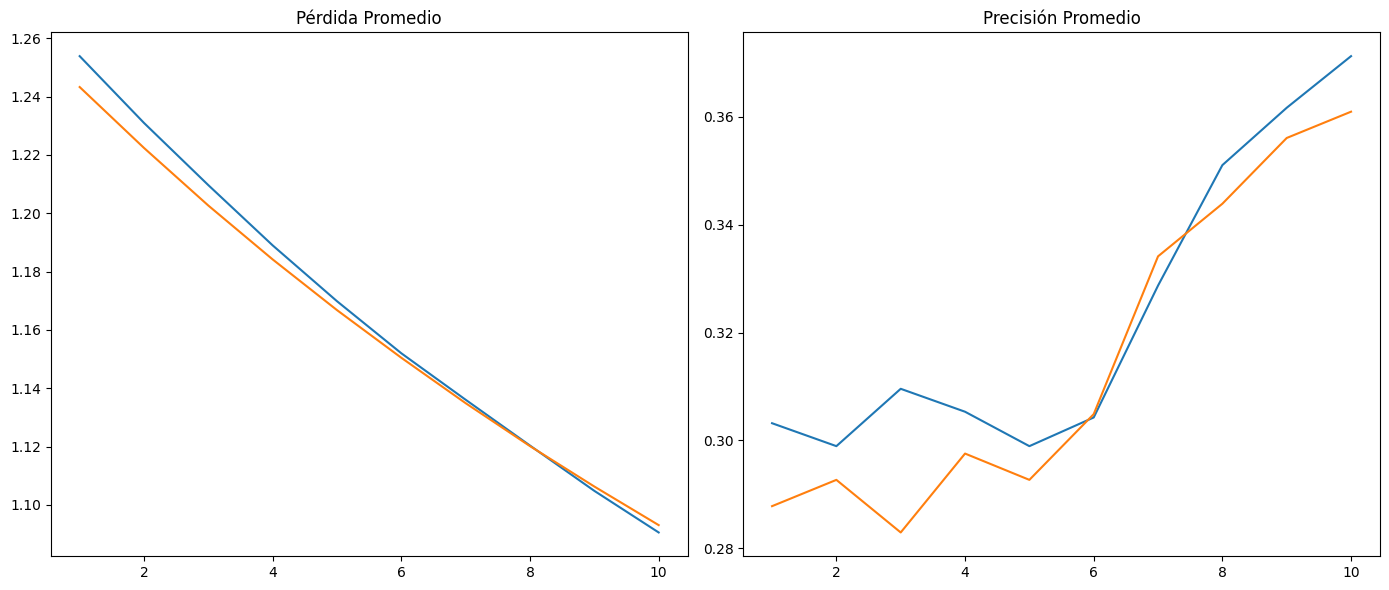

Grado 5: Pérdida Promedio = 1.0119, Precisión Promedio = 0.4333, Tiempo Promedio = 1.6846


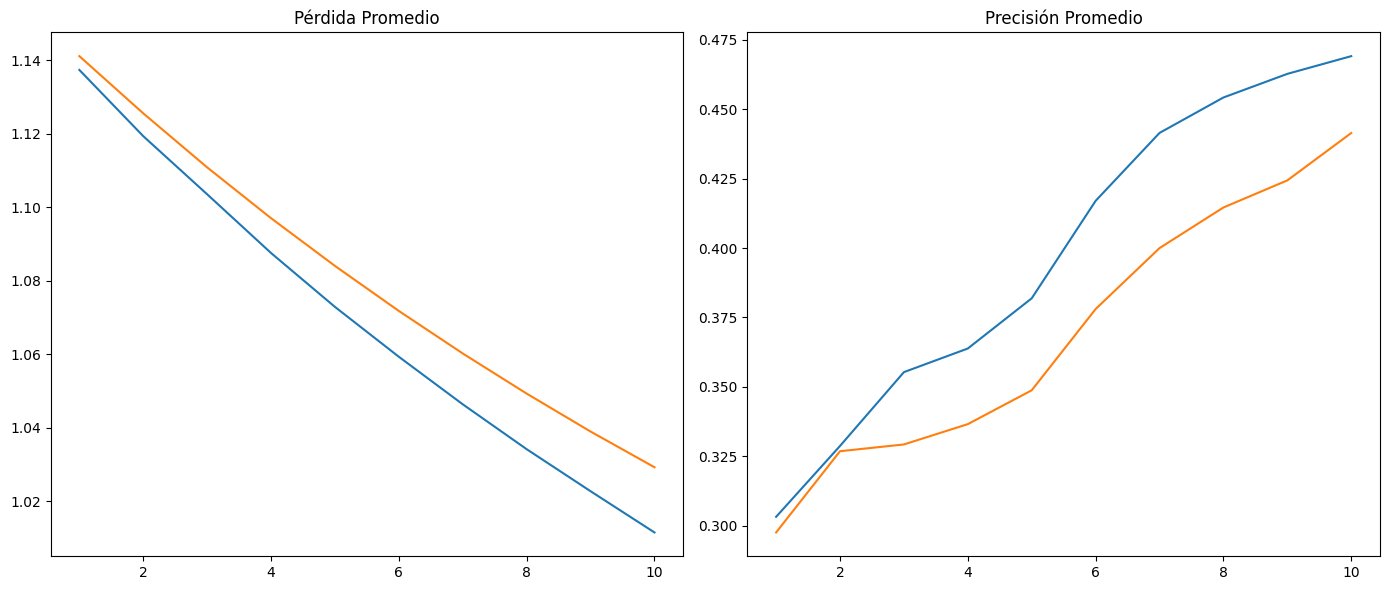

Grado 10: Pérdida Promedio = 1.2472, Precisión Promedio = 0.3333, Tiempo Promedio = 1.8816


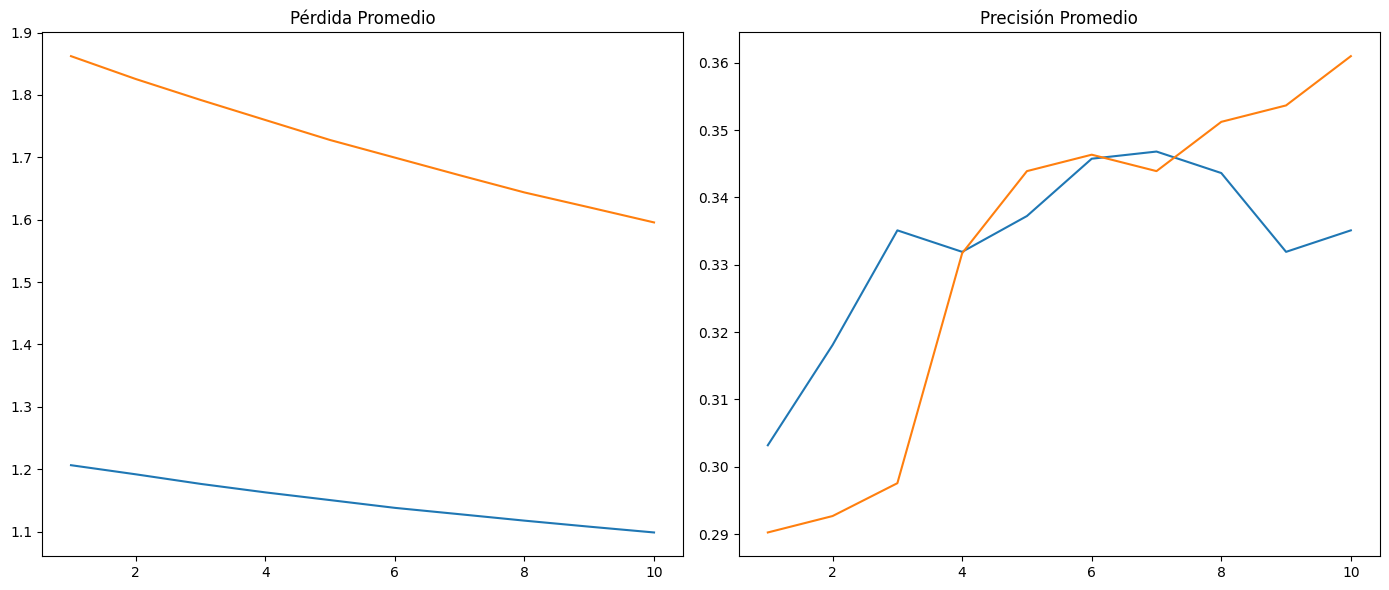

In [ ]:
print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Chebyshev)")
print("="*40)

scoreMean_cheb = {}
for deg in degrees:
    scoreMean_cheb[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_cheb[deg][0]:.4f}, Precisión Promedio = {scoreMean_cheb[deg][1]:.4f}, Tiempo Promedio = {scoreMean_cheb[deg][2]:.4f}")
    plot_cv_average_history(history[deg])

In [ ]:
results = {deg: calculator(scores[deg], times[deg]) for deg in degrees}


# ===== CSV =====
os.makedirs("resultados", exist_ok=True)

data = []
for deg in degrees:
    loss, acc, t = results[deg]

    # Recuperar mejor N encontrado en el grid search
    best_n = max(search_results[deg], key=search_results[deg].get)

    data.append({
        "Polinomio": "Shmaliy",
        "Grado": deg,
        "Mejor_N": best_n,
        "Loss_Promedio": round(loss, 6),
        "Accuracy_Promedio": round(acc, 6),
        "Tiempo_Promedio(s)": round(t, 2)
    })

pd.DataFrame(data).to_csv(
    "resultados/resultados_shmaliy_specialist.csv",
    index=False,
    sep=';'
)


# ===== GRÁFICAS =====
for deg in degrees:
    save_image_plot(history[deg], deg)

print("Proceso finalizado correctamente")

Proceso finalizado correctamente
